In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as patches

In [2]:
non_pawn_row = ['toren', 'paard', 'loper', 'koningin', 'koning', 'loper', 'paard', 'toren']
pawn_row = ['pion' for _ in range(8)]
empty_row = [['leeg', 0] for _ in range(8)]

In [3]:
bord = [[['zwart', p] for p in non_pawn_row], [['zwart', p] for p in pawn_row], empty_row, empty_row, empty_row, empty_row, [['wit', p] for p in pawn_row], [['wit', p] for p in non_pawn_row]]

In [60]:
#bord

In [26]:
def toon_bord(board):

    images = []

    for i in range(8):  
        for j in range(8):
            piece = board[i][j]
            if piece[0] == 'leeg':
                images.append(Image.open("icons/leeg.png"))
            else:
                images.append(Image.open(f"icons/{piece[0]}_{piece[1]}.png"))
                
    rows, cols = 8, 8
    
    # row + column labels
    row_labels = ['8', '7', '6', '5', '4', '3', '2', '1']
    col_labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
    
    fig, axes = plt.subplots(
        rows, cols,
        figsize=(0.5 * cols, 0.5 * rows),
        gridspec_kw=dict(wspace=0, hspace=0),
        #sharex=True, sharey=True,
    )
    
    axes = np.array(axes)
    
    # ===== 1. Show images, remove ticks =====
    for idx, img in enumerate(images):
        r, c = divmod(idx, cols)
        ax = axes[r, c]
        ax.imshow(img)
        ax.set_xticks([])
        ax.set_yticks([])
    
    # ===== 2. Add ROW LABELS on the left of each row =====
    for r in range(rows):
        ax = axes[r, 0]
        ax.set_ylabel(
            row_labels[r],
            rotation=0,
            labelpad=20,              # pushes label leftward
            va="center",
            ha="center"
        )
    
    # ===== 3. Add COLUMN LABELS centered under each column =====
    for c in range(cols):
        ax = axes[rows-1, c]
        ax.set_xlabel(
            col_labels[c],
            labelpad=20,             # pushes label downward
            ha="center",
            va="center"
        )
    
    # ===== 4. Build roster gridlines using spines =====
    # Hide all spines first
    for ax in axes.ravel():
        for s in ax.spines.values():
            s.set_visible(False)
    
    # Turn on only the necessary ones
    for r in range(rows):
        for c in range(cols):
            ax = axes[r, c]
    
            # outer border
            if r == 0:
                ax.spines["top"].set_visible(True)
            if r == rows - 1:
                ax.spines["bottom"].set_visible(True)
            if c == 0:
                ax.spines["left"].set_visible(True)
            if c == cols - 1:
                ax.spines["right"].set_visible(True)
    
            # inner grid lines (each one drawn once)
            if r < rows - 1:
                ax.spines["bottom"].set_visible(True)
            if c < cols - 1:
                ax.spines["right"].set_visible(True)
    
    # Style visible borders
    for ax in axes.ravel():
        for s in ax.spines.values():
            if s.get_visible():
                s.set_linewidth(2)
                s.set_edgecolor("black")
    
    plt.show()

In [5]:
def test_move(orig, dest):

    column_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7}
    row_map = {'1': 7, '2': 6, '3': 5, '4': 4, '5': 3, '6': 2, '7': 1, '8': 0}

    try: 
        orig_pos = [row_map[orig[1]], column_map[orig[0]]]
        print(f"Origin position: {orig_pos}")
    except:
        print("Origin position: invalid")

    try:
        dest_pos = [row_map[dest[1]], column_map[dest[0]]]
        print(f"Destination position: {dest_pos}")
    except:
        print("Destination position: invalid")

In [6]:
test_move('K3', 'F8')

Origin position: invalid
Destination position: [0, 5]


In [7]:
def geldige_zetten_pion(bord, kleur, van_rij, van_kol):
    
    geldige_zetten = []
    
    if kleur == 'wit' and van_rij != 0:
        
        if bord[van_rij-1][van_kol][0] == 'leeg':
            geldige_zetten.append([van_rij-1, van_kol])
        if van_rij == 6 and bord[van_rij-2][van_kol][0] == 'leeg':
            geldige_zetten.append([van_rij-2, van_kol])
        if van_kol != 0 and bord[van_rij-1][van_kol-1][0] == 'zwart':
            geldige_zetten.append([van_rij-1, van_kol-1])
        if van_kol != 7 and bord[van_rij-1][van_kol+1][0] == 'zwart':
            geldige_zetten.append([van_rij-1, van_kol+1])

    if kleur == 'zwart' and van_rij != 7:
        
        if bord[van_rij+1][van_kol][0] == 'leeg':
            geldige_zetten.append([van_rij+1, van_kol])
        if van_rij == 1 and bord[van_rij+2][van_kol][0] == 'leeg':
            geldige_zetten.append([van_rij+2, van_kol])
        if van_kol != 0 and bord[van_rij+1][van_kol-1][0] == 'wit':
            geldige_zetten.append([van_rij+1, van_kol-1])
        if van_kol != 7 and bord[van_rij+1][van_kol+1][0] == 'wit':
            geldige_zetten.append([van_rij+1, van_kol+1])

    return geldige_zetten

In [8]:
def geldige_zetten_paard(bord, kleur, van_rij, van_kol):
    
    zetten = [[van_rij-2, van_kol-1], [van_rij-2, van_kol+1], [van_rij+2, van_kol-1], [van_rij+2, van_kol+1], [van_rij-1, van_kol+2], [van_rij-1, van_kol-2], [van_rij+1, van_kol+2], [van_rij+1, van_kol-2]]
    
    geldige_zetten = []
    
    for zet in zetten:
        if (zet[0] >= 0) and (zet[0] <= 7) and (zet[1] >= 0) and (zet[1] <= 7):
            geldige_zetten.append(zet)

    return geldige_zetten

In [9]:
def geldige_zetten_toren(bord, kleur, van_rij, van_kol):
    
    geldige_zetten = []
    
    if van_rij != 7:
        for i in range(7 - van_rij):
            if bord[van_rij+i+1][van_kol][0] == 'leeg':
                geldige_zetten.append([van_rij+i+1, van_kol])
            elif bord[van_rij+i+1][van_kol][0] == kleur:
                break
            else:
                geldige_zetten.append([van_rij+i+1, van_kol])
                break

    if van_rij != 0:
        for i in range(van_rij):
            if bord[van_rij-i-1][van_kol][0] == 'leeg':
                geldige_zetten.append([van_rij-i-1, van_kol])
            elif bord[van_rij-i-1][van_kol][0] == kleur:
                break
            else:
                geldige_zetten.append([van_rij-i-1, van_kol])
                break

    if van_kol != 7:
        for i in range(7 - van_kol):
            if bord[van_rij][van_kol+i+1][0] == 'leeg':
                geldige_zetten.append([van_rij, van_kol+i+1])
            elif bord[van_rij][van_kol+i+1][0] == kleur:
                break
            else:
                geldige_zetten.append([van_rij, van_kol+i+1])
                break

    if van_kol != 0:
        for i in range(van_kol):
            if bord[van_rij][van_kol-i-1][0] == 'leeg':
                geldige_zetten.append([van_rij, van_kol-i-1])
            elif bord[van_rij][van_kol-i-1][0] == kleur:
                break
            else:
                geldige_zetten.append([van_rij, van_kol-i-1])
                break
            
    return geldige_zetten

In [10]:
def geldige_zetten_loper(bord, kleur, van_rij, van_kol):
    
    geldige_zetten = []

    rij = van_rij + 1
    kol = van_kol + 1

    while rij < 8 and kol < 8:
        if bord[rij][kol][0] == 'leeg':
            geldige_zetten.append([rij, kol])
            rij += 1
            kol += 1
        elif bord[rij][kol][0] == kleur:
            break
        else:
            geldige_zetten.append([rij, kol])
            break

    rij = van_rij + 1
    kol = van_kol - 1

    while rij < 8 and kol >= 0:
        if bord[rij][kol][0] == 'leeg':
            geldige_zetten.append([rij, kol])
            rij += 1
            kol -= 1
        elif bord[rij][kol][0] == kleur:
            break
        else:
            geldige_zetten.append([rij, kol])
            break

    rij = van_rij - 1
    kol = van_kol - 1

    while rij >= 0 and kol >= 0:
        if bord[rij][kol][0] == 'leeg':
            geldige_zetten.append([rij, kol])
            rij -= 1
            kol -= 1
        elif bord[rij][kol][0] == kleur:
            break
        else:
            geldige_zetten.append([rij, kol])
            break

    rij = van_rij - 1
    kol = van_kol + 1

    while rij >= 0 and kol < 8:
        if bord[rij][kol][0] == 'leeg':
            geldige_zetten.append([rij, kol])
            rij -= 1
            kol += 1
        elif bord[rij][kol][0] == kleur:
            break
        else:
            geldige_zetten.append([rij, kol])
            break
            
    return geldige_zetten

In [11]:
def geldige_zetten_koning(bord, kleur, van_rij, van_kol):

    zetten = [[van_rij-1, van_kol-1], [van_rij-1, van_kol], [van_rij-1, van_kol+1], [van_rij, van_kol-1], [van_rij, van_kol+1], [van_rij+1, van_kol-1], [van_rij+1, van_kol], [van_rij+1, van_kol+1]]

    geldige_zetten = []
    
    for zet in zetten:
        if (zet[0] >= 0) and (zet[0] <= 7) and (zet[1] >= 0) and (zet[1] <= 7):
            geldige_zetten.append(zet)
            
    return geldige_zetten

In [12]:
def geldige_zetten_koningin(bord, kleur, van_rij, van_kol):

    geldige_zetten = geldige_zetten_loper(bord, kleur, van_rij, van_kol) + geldige_zetten_toren(bord, kleur, van_rij, van_kol)
    
    return geldige_zetten

In [13]:
geldige_zetten_pion(bord, 'wit', 6, 5)

[[5, 5], [4, 5]]

In [14]:
geldige_zetten_paard(bord, 'hihi', 4, 3)

[[2, 2], [2, 4], [6, 2], [6, 4], [3, 5], [3, 1], [5, 5], [5, 1]]

In [15]:
geldige_zetten_toren(bord, 'wit', 5, 0)

[[4, 0],
 [3, 0],
 [2, 0],
 [1, 0],
 [5, 1],
 [5, 2],
 [5, 3],
 [5, 4],
 [5, 5],
 [5, 6],
 [5, 7]]

In [16]:
geldige_zetten_loper(bord, 'zwart', 1, 3)

[[2, 4], [3, 5], [4, 6], [5, 7], [2, 2], [3, 1], [4, 0]]

In [17]:
geldige_zetten_koning(bord, 'bla', 3, 3)

[[2, 2], [2, 3], [2, 4], [3, 2], [3, 4], [4, 2], [4, 3], [4, 4]]

In [18]:
g = geldige_zetten_koningin(bord, 'wit', 5, 5)
g

[[4, 4],
 [3, 3],
 [2, 2],
 [1, 1],
 [4, 6],
 [3, 7],
 [4, 5],
 [3, 5],
 [2, 5],
 [1, 5],
 [5, 6],
 [5, 7],
 [5, 4],
 [5, 3],
 [5, 2],
 [5, 1],
 [5, 0]]

In [19]:
[5, 1] in g

True

In [29]:
def doe_zet(bord, kleur, van, naar):

    volgend_bord = [rij[:] for rij in bord]
    
    column_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7}
    row_map = {'1': 7, '2': 6, '3': 5, '4': 4, '5': 3, '6': 2, '7': 1, '8': 0}

    van_rij = row_map[van[1]]
    van_kol = column_map[van[0]]

    naar_rij = row_map[naar[1]]
    naar_kol = column_map[naar[0]]

    if (bord[van_rij][van_kol][0] != kleur) or (bord[naar_rij][naar_kol][0] == kleur):
        print("Ongeldige zet!")
        toon_bord(volgend_bord)

    else:
        function_name = f'geldige_zetten_{bord[van_rij][van_kol][1]}'
        function = globals().get(function_name)
        geldige_zetten = function(bord, kleur, van_rij, van_kol)
        
        if [naar_rij, naar_kol] in geldige_zetten:

            volgend_bord[naar_rij][naar_kol] = bord[van_rij][van_kol]
            volgend_bord[van_rij][van_kol] = ['leeg', 0]
            
            toon_bord(volgend_bord)

        else:
            print('Ongeldige zet')
            toon_bord(volgend_bord)
        
    return volgend_bord

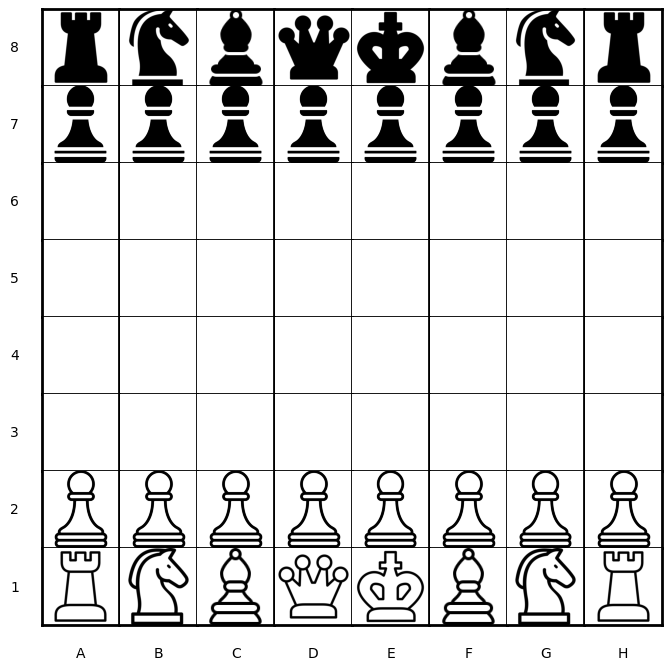

In [21]:
toon_bord(bord)

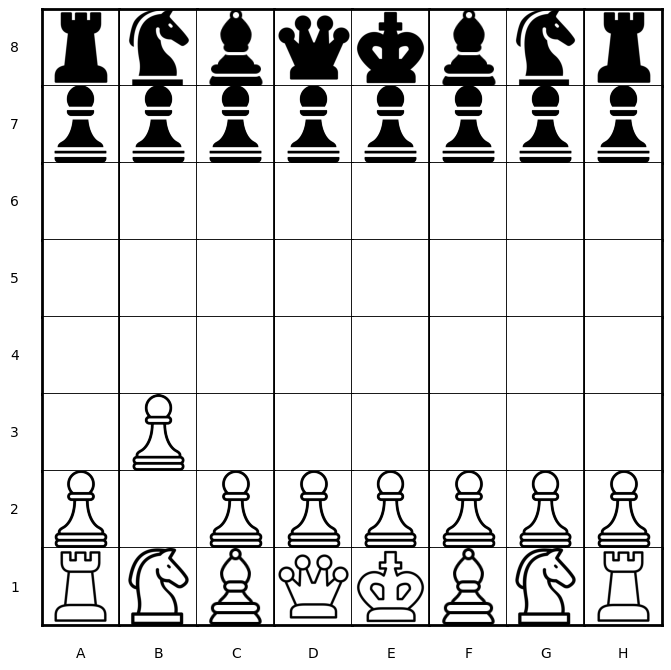

In [22]:
bord = doe_zet(bord, 'wit', 'B2', 'B3')

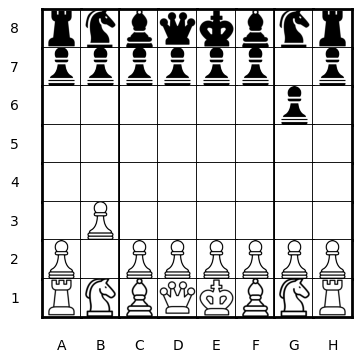

In [28]:
bord = doe_zet(bord, 'zwart', 'G7', 'G6')

Ongeldige zet!


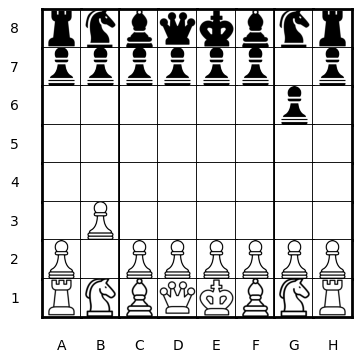

In [30]:
bord = doe_zet(bord, 'wit', 'A2', 'B1')